# FDSI benchmark: results

How much online adaptation improves motor-unit tracking over no adaptation, across the FDSI
benchmark's 100 recordings (5 subjects × 5 contractions × 4 SNR levels), for each way of
tuning it: `sv_loss` alone, the Pareto front of `wh_loss` and `sv_loss` (min-sv member), each
with `sv_loss` averaged or summed over units, and the ground-truth RoA as an upper bound.

This notebook only reads the tables written by `python -m benchmarks.fdsi collect` under the
spec's `outputs_root/tables/`. Set the `FDSI_SPEC` environment
variable to read another spec's tables (e.g. `benchmarks/fdsi/benchmark_smoke.yaml`).

> **Results pending.** This page shows the report's code; its figures and tables are added
> when the release benchmark is run (see the benchmark page's release checklist).

In [21]:
import os
import sys
from pathlib import Path

os.chdir(os.path.expanduser("~/adapt_decomp"))
REPO_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents) if (p / "benchmarks" / "fdsi").is_dir()
)
sys.path.insert(0, str(REPO_ROOT))  # so that benchmarks.fdsi imports from any working directory

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

from adapt_decomp.utils.plots import (
    plot_metric_heatmap,
    plot_phase_bar,
    plot_search_front,
    plot_search_landscape,
    plot_search_parameters,
)
from benchmarks.fdsi import report
from benchmarks.fdsi.spec import load_spec

spec = load_spec(os.environ.get("FDSI_SPEC", "benchmarks/fdsi/benchmark.yaml"))
tables = report.load_tables(spec)
units, calib_units = tables["units"], tables["calibration_units"]
searches, best_configs = tables["searches"], tables["best_configs"].set_index("search")

LABELS = {branch: report.config_label(spec, branch) for branch in spec.branches}
CONFIGS = report.config_order(spec)
FIXED, ADAPTED = report.FIXED_LABEL, CONFIGS[1:]
CONDITIONS, SNR_LEVELS = spec.grid.conditions, spec.grid.snr_levels
TRIANGULAR = [c for c in CONDITIONS if "triangular" in c]
PALETTE = dict(zip(CONFIGS, sns.color_palette("tab10", len(CONFIGS))))
pd.set_option("display.precision", 2)

print(
    f"{spec.name}: {len(spec.recordings())} recordings, {len(CONFIGS)} configs, {len(units)} unit rows"
)

benchmark_v1_1: 100 recordings, 6 configs, 4710 unit rows


## 1. Run overview

Which tasks ran, from which commit, on which machines and for how long (every output also
has its own `*.meta.yaml` with the full record).

In [23]:
display(report.provenance_summary(tables["provenance"]))

,n_tasks,compute_h,commits,any_dirty,hosts,cpus,done
stage,,,,,,,
apply,600,41.02,2,True,61,AMD EPYC 7742 64-Core Processor,600
calibrate,100,2.54,1,False,26,AMD EPYC 7742 64-Core Processor,100
search,5,5.97,1,True,4,AMD EPYC 7742 64-Core Processor,5


### Calibration

CBSS on the first 5 s of each recording, keeping the units that match a simulated motor unit
with RoA ≥ 90 %. Per condition and SNR: units per recording, their RoA against the ground
truth, and how many have SIL ≥ 0.9 (all averaged over subjects).

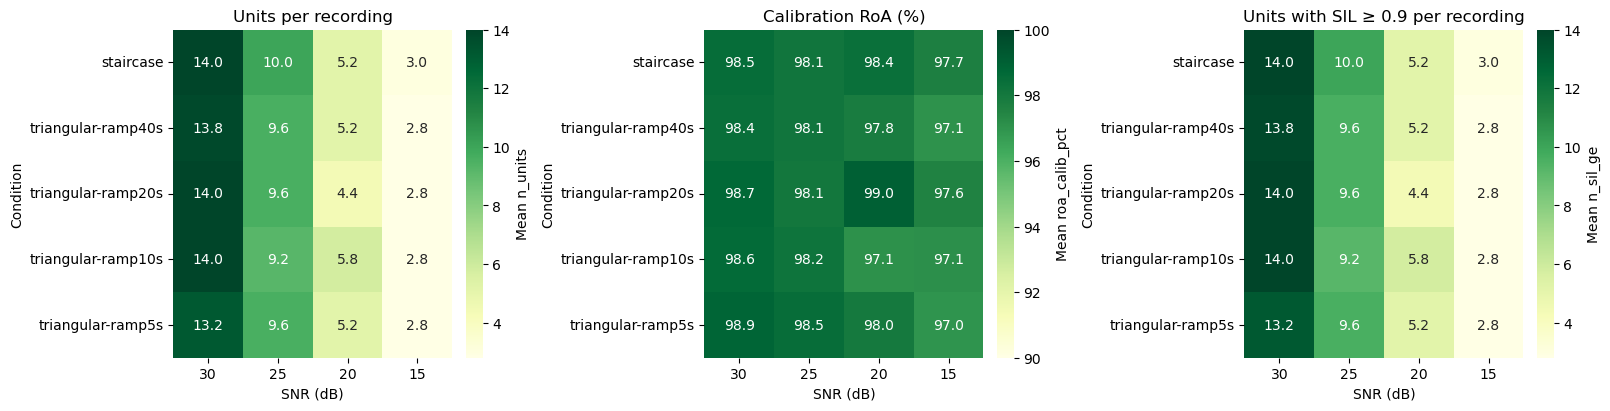

In [24]:
calib_rec = report.units_per_recording(
    calib_units,
    sil_col="sil_calib",
    roa_col="roa_calib",
    by=["recording", "sub", "condition", "snr"],
).assign(config="Calibration")
calib_units_c = calib_units.assign(config="Calibration")

fig, axs = plt.subplots(1, 3, figsize=(16, 4), layout="constrained")
plot_metric_heatmap(calib_rec, "n_units", ["Calibration"], CONDITIONS, SNR_LEVELS, axs=axs[[0]])
plot_metric_heatmap(
    calib_units_c,
    "roa_calib_pct",
    ["Calibration"],
    CONDITIONS,
    SNR_LEVELS,
    vmin=90,
    vmax=100,
    axs=axs[[1]],
)
plot_metric_heatmap(calib_rec, "n_sil_ge", ["Calibration"], CONDITIONS, SNR_LEVELS, axs=axs[[2]])
for ax, title in zip(
    axs, ["Units per recording", "Calibration RoA (%)", "Units with SIL ≥ 0.9 per recording"]
):
    ax.set_title(title)
plt.show()

## 2. Searches

Each search tuned `wh_learning_rate`, `sv_learning_rate` and `centroid_momentum` on the pool's
recordings, from the end of their calibration window. The chosen trial's parameters are the
config applied to every recording.

In [25]:
display(
    best_configs.set_index("config")[
        [
            "objectives",
            "selection",
            "sv_loss_reduction",
            "chosen_trial",
            "wh_learning_rate",
            "sv_learning_rate",
            "centroid_momentum",
        ]
    ]
)

,objectives,selection,sv_loss_reduction,chosen_trial,wh_learning_rate,sv_learning_rate,centroid_momentum
config,,,,,,,
"sv_loss, mean",sv_loss,NaN,mean,21,9.18e-04,4.25e-03,0.76
"sv_loss, sum",sv_loss,NaN,sum,9,2.44e-03,5.99e-03,0.04
"Pareto min-sv, mean","wh_loss,sv_loss",min_sv_loss,mean,9,2.44e-03,5.99e-03,0.04
"Pareto min-sv, sum","wh_loss,sv_loss",min_sv_loss,sum,9,2.44e-03,5.99e-03,0.04
RoA (oracle),roa,NaN,mean,9,2.44e-03,5.99e-03,0.04


### Landscapes

Every trial's pooled RoA against the pooled losses: whether a lower loss means better
tracking, and where the chosen trial sits.

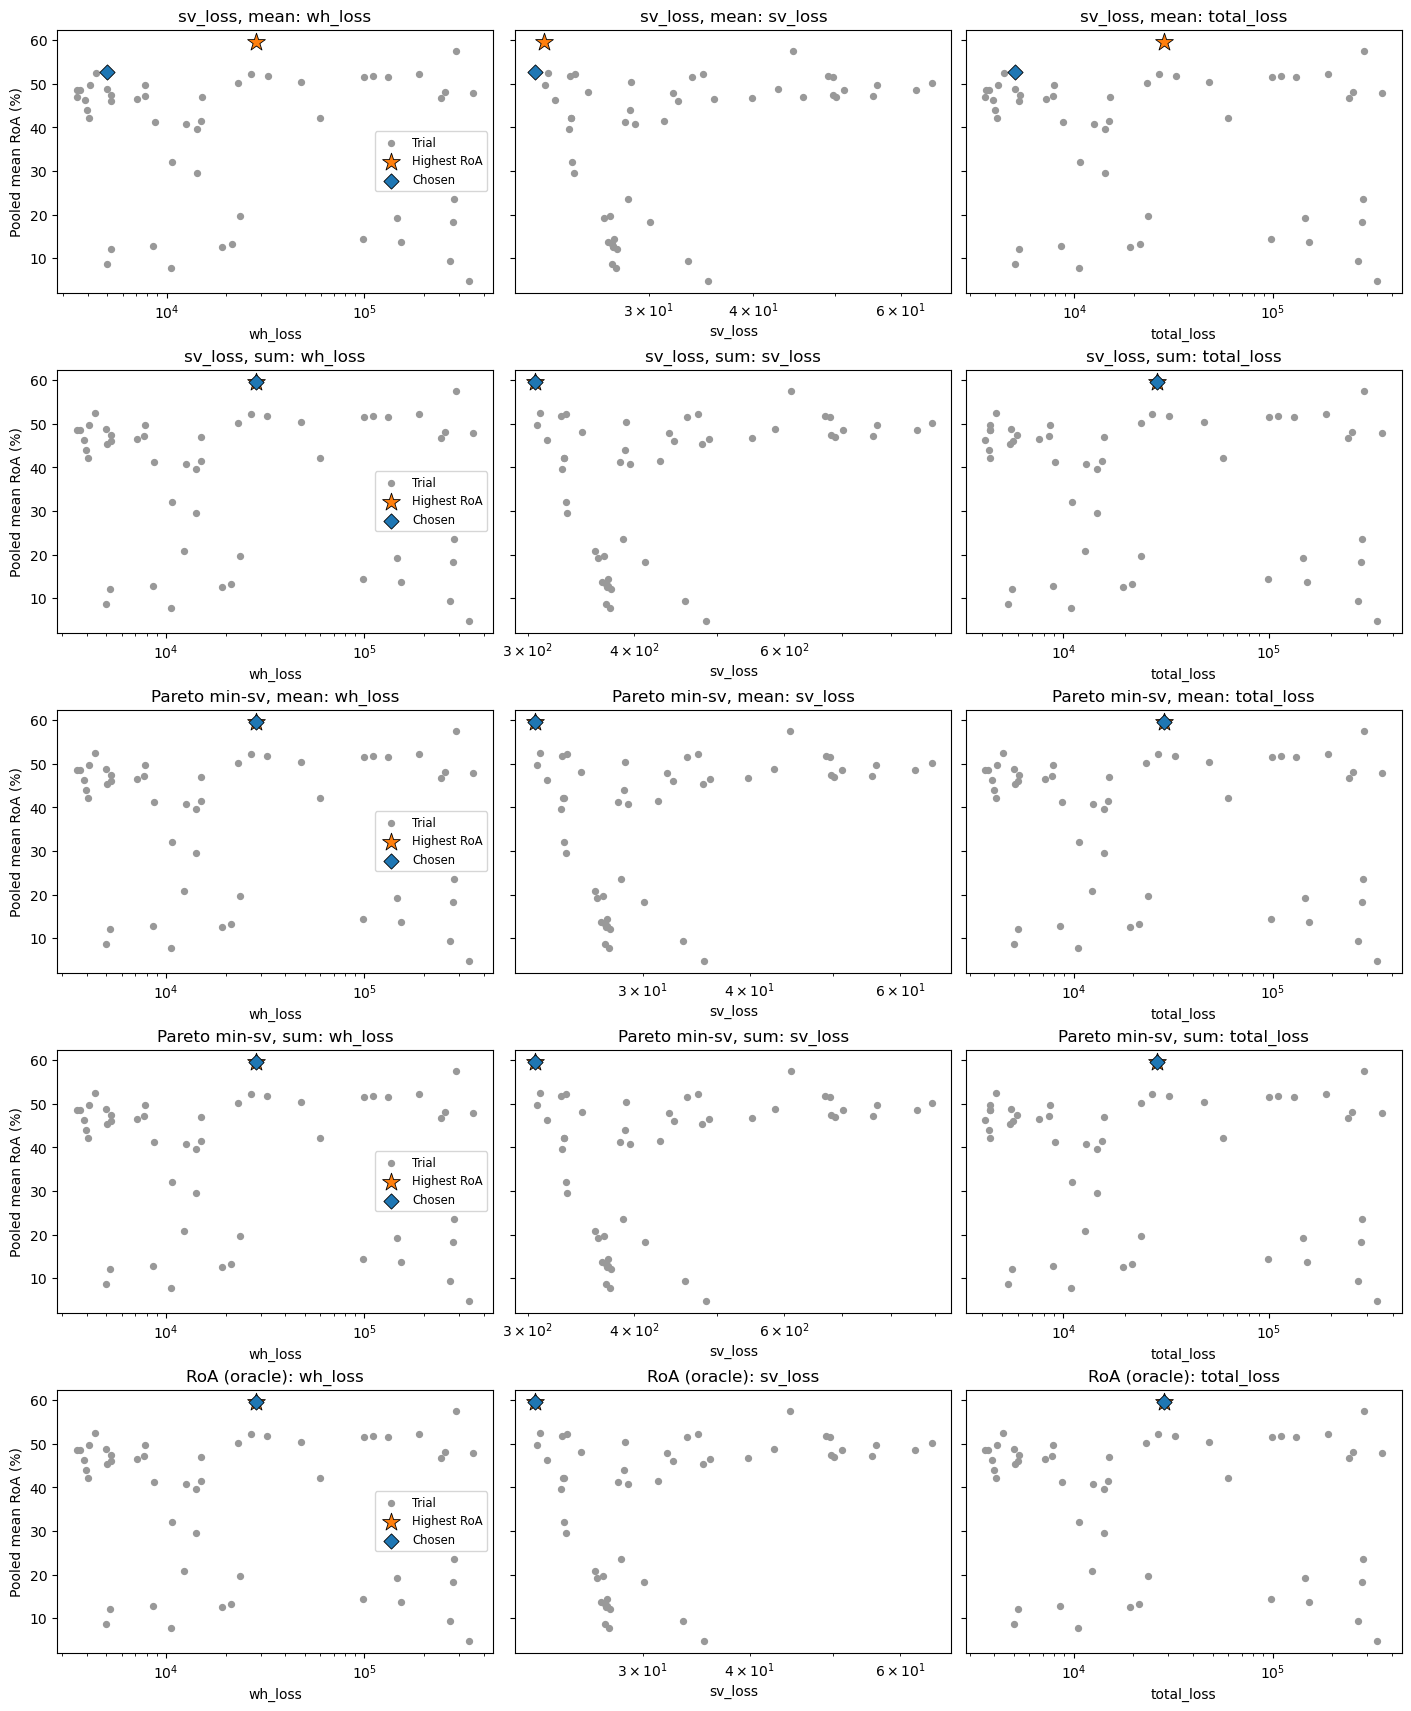

In [26]:
names = list(best_configs.index)
fig, axs = plt.subplots(
    len(names), 3, figsize=(14, 3.4 * len(names)), layout="constrained", sharey=True, squeeze=False
)
for row, name in zip(axs, names):
    plot_search_landscape(
        report.complete_trials(searches, name),
        best_configs.loc[name, "chosen_trial"],
        title=LABELS[name],
        axs=row,
    )
plt.show()

### Pareto fronts

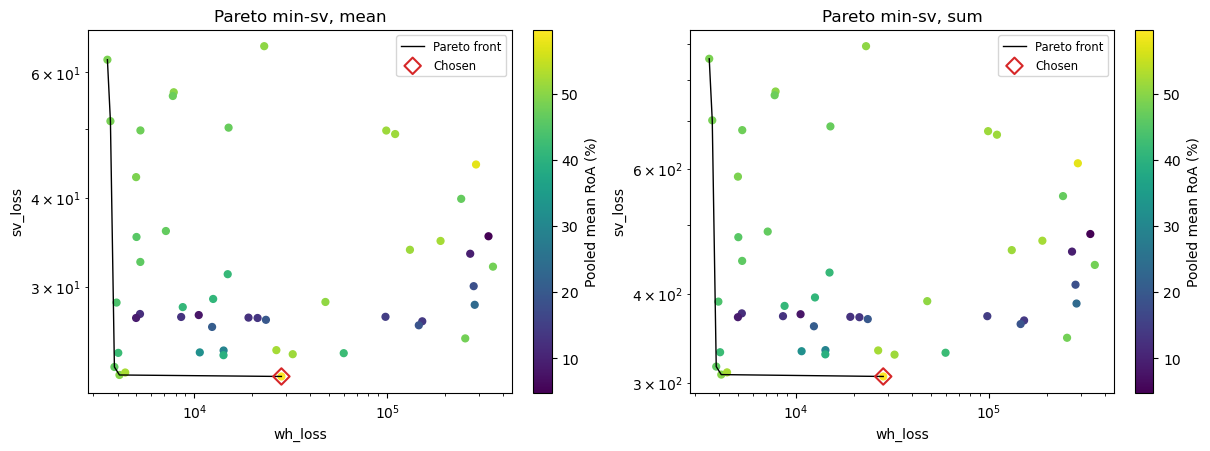

In [27]:
pareto = [
    n
    for n in names
    if "values_wh_loss" in report.objective_columns(report.complete_trials(searches, n))
]
if pareto:
    fig, axs = plt.subplots(
        1, len(pareto), figsize=(6 * len(pareto), 4.4), layout="constrained", squeeze=False
    )
    for ax, name in zip(axs[0], pareto):
        trials = report.complete_trials(searches, name)
        plot_search_front(
            trials,
            report.front_numbers(trials),
            best_configs.loc[name, "chosen_trial"],
            title=LABELS[name],
            ax=ax,
        )
    plt.show()

### Convergence

The best objective value reached so far at each trial (for a Pareto search, its `sv_loss`,
which the min-sv selection uses).

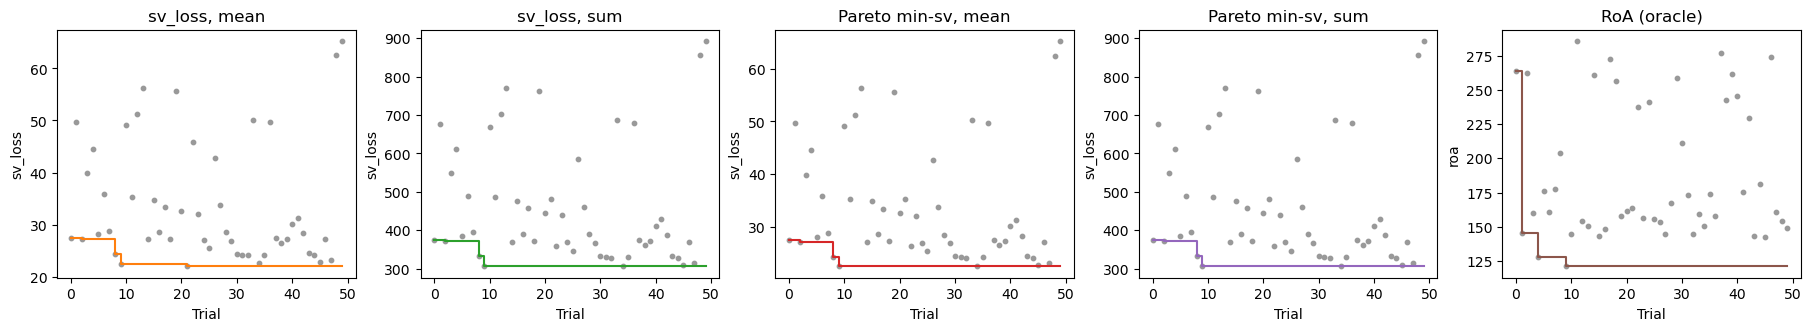

In [28]:
fig, axs = plt.subplots(
    1, len(names), figsize=(3.6 * len(names), 3.2), layout="constrained", squeeze=False
)
for ax, name in zip(axs[0], names):
    trials = report.complete_trials(searches, name)
    columns = report.objective_columns(trials)
    column = "values_sv_loss" if "values_sv_loss" in columns else columns[0]
    curve = report.best_so_far(trials, column)
    ax.scatter(curve["number"], curve["value"], s=10, color="0.6")
    ax.step(curve["number"], curve["best_so_far"], where="post", color=PALETTE[LABELS[name]])
    ax.set(title=LABELS[name], xlabel="Trial", ylabel=column.split("_", 1)[1])
plt.show()

### Hyperparameter scales

Pooled RoA of every trial of every search against each parameter: how sensitive tracking is
to each parameter's scale, whichever objective chose it. The searches share a seed, so their
random start-up trials are the same parameter sets and overlap here.

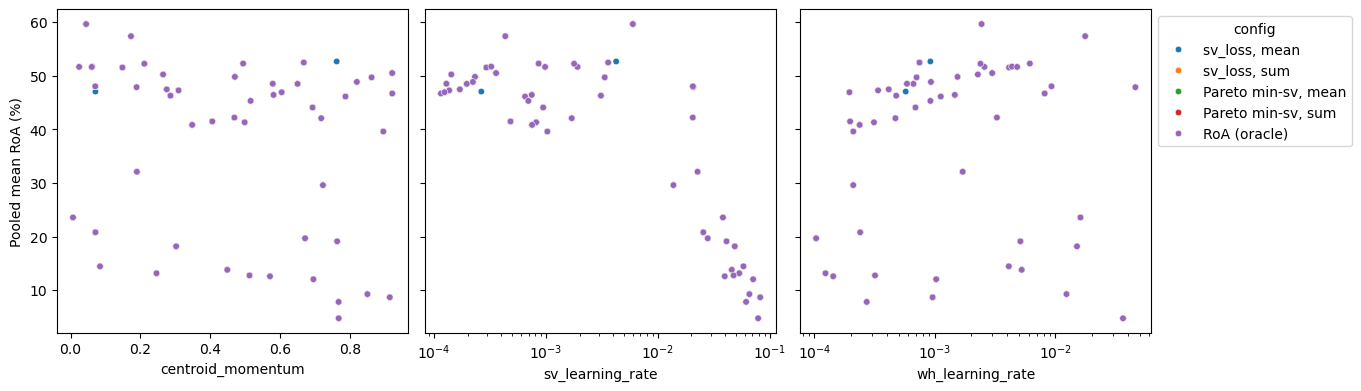

In [29]:
plot_search_parameters(report.complete_trials(searches), hue="config")
plt.show()

## 3. Gains over no adaptation

RoA of every tracked unit over the whole recording (the calibration window included), per
config.

In [30]:
display(
    report.summary_by_config(units)
    .reindex(CONFIGS)
    .rename(columns={"pct_ge_threshold": "% units RoA ≥ 90"})
)

,n_units,mean,median,std,% units RoA ≥ 90
config,,,,,
No adaptation,785,34.21,31.51,13.06,0.00
"sv_loss, mean",785,72.18,92.52,34.63,54.52
"sv_loss, sum",785,74.55,91.50,32.97,54.65
"Pareto min-sv, mean",785,74.55,91.50,32.97,54.65
"Pareto min-sv, sum",785,74.55,91.50,32.97,54.65
RoA (oracle),785,74.55,91.50,32.97,54.65


### Units per recording

Mean over recordings of the units tracked, those with SIL ≥ 0.9 and those with RoA ≥ 90 %,
both over the whole recording, next to the calibration's own.

In [31]:
per_rec = report.units_per_recording(units, by=["config", "recording"])
counts = per_rec.groupby("config", sort=False)[
    ["n_units", "n_sil_ge", "pct_sil_ge", "n_roa_ge"]
].mean()
calib_counts = (
    calib_rec[["n_units", "n_sil_ge", "pct_sil_ge", "n_roa_ge"]].mean().rename("Calibration")
)
display(
    pd.concat([calib_counts.to_frame().T, counts.reindex(CONFIGS)]).rename(
        columns={"n_sil_ge": "SIL ≥ 0.9", "pct_sil_ge": "% SIL ≥ 0.9", "n_roa_ge": "RoA ≥ 90 %"}
    )
)

,n_units,SIL ≥ 0.9,% SIL ≥ 0.9,RoA ≥ 90 %
Calibration,7.85,7.85,100.00,7.85
No adaptation,7.85,7.35,96.08,0.00
"sv_loss, mean",7.85,3.44,46.14,4.28
"sv_loss, sum",7.85,3.37,43.43,4.29
"Pareto min-sv, mean",7.85,3.37,43.43,4.29
"Pareto min-sv, sum",7.85,3.37,43.43,4.29
RoA (oracle),7.85,3.37,43.43,4.29


### Paired per-unit gain

Each adapted config against no adaptation, unit by unit (same calibrations, so the same units).

In [32]:
display(report.paired_summary(units, [(FIXED, config) for config in ADAPTED]))

n_units  mean_before  mean_after  \
before        after                                                   
No adaptation sv_loss, mean            785        34.21       72.18   
              sv_loss, sum             785        34.21       74.55   
              Pareto min-sv, mean      785        34.21       74.55   
              Pareto min-sv, sum       785        34.21       74.55   
              RoA (oracle)             785        34.21       74.55   

                                   mean_delta  median_before  median_after  \
before        after                                                          
No adaptation sv_loss, mean             37.97          31.51         92.52   
              sv_loss, sum              40.34          31.51         91.50   
              Pareto min-sv, mean       40.34          31.51         91.50   
              Pareto min-sv, sum        40.34          31.51         91.50   
              RoA (oracle)              40.34          31.51         91.50   

                                   median_delta  pct_improved  pct_unchanged  \
before        after                                                            
No adaptation sv_loss, mean               48.51         81.15           0.00   
              sv_loss, sum                51.52         83.69           0.38   
              Pareto min-sv, mean         51.52         83.69           0.38   
              Pareto min-sv, sum          51.52         83.69           0.38   
              RoA (oracle)                51.52         83.69           0.38   

                                   pct_worse  wilcoxon_p  
before        after                                       
No adaptation sv_loss, mean            18.85   3.14e-100  
              sv_loss, sum             15.92   2.90e-108  
              Pareto min-sv, mean      15.92   2.90e-108  
              Pareto min-sv, sum       15.92   2.90e-108  
              RoA (oracle)             15.92   2.90e-108

AttributeError: module 'benchmarks.fdsi.report' has no attribute 'ROA_PCT'

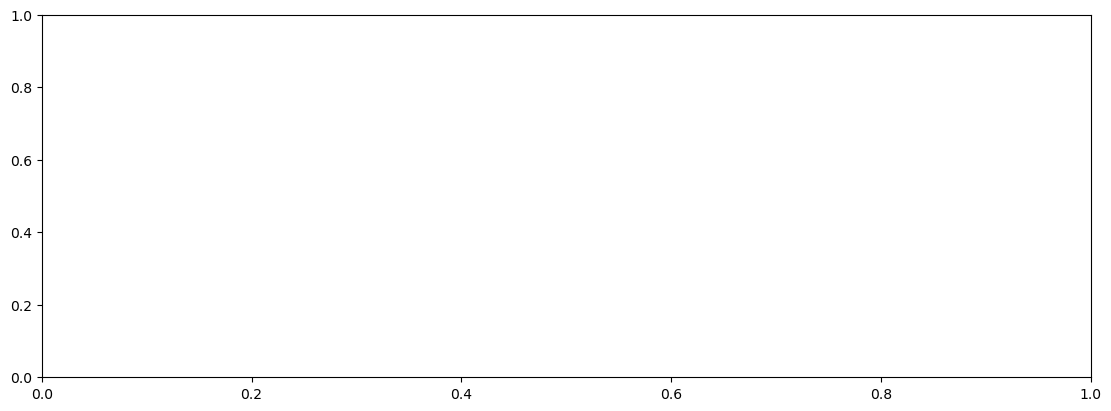

In [33]:
fig, ax = plt.subplots(figsize=(11, 4), layout="constrained")
sns.boxplot(
    data=units,
    x="config",
    y=report.ROA_PCT,
    order=CONFIGS,
    hue="config",
    palette=PALETTE,
    legend=False,
    flierprops=dict(marker=".", markersize=3, alpha=0.4),
    ax=ax,
)
ax.set(xlabel="", ylabel="RoA, whole recording (%)", ylim=(0, 102))
plt.show()

## 4. Across contractions and SNR

Mean RoA over the whole recording and the share of units at or above 90 %, per contraction and SNR.

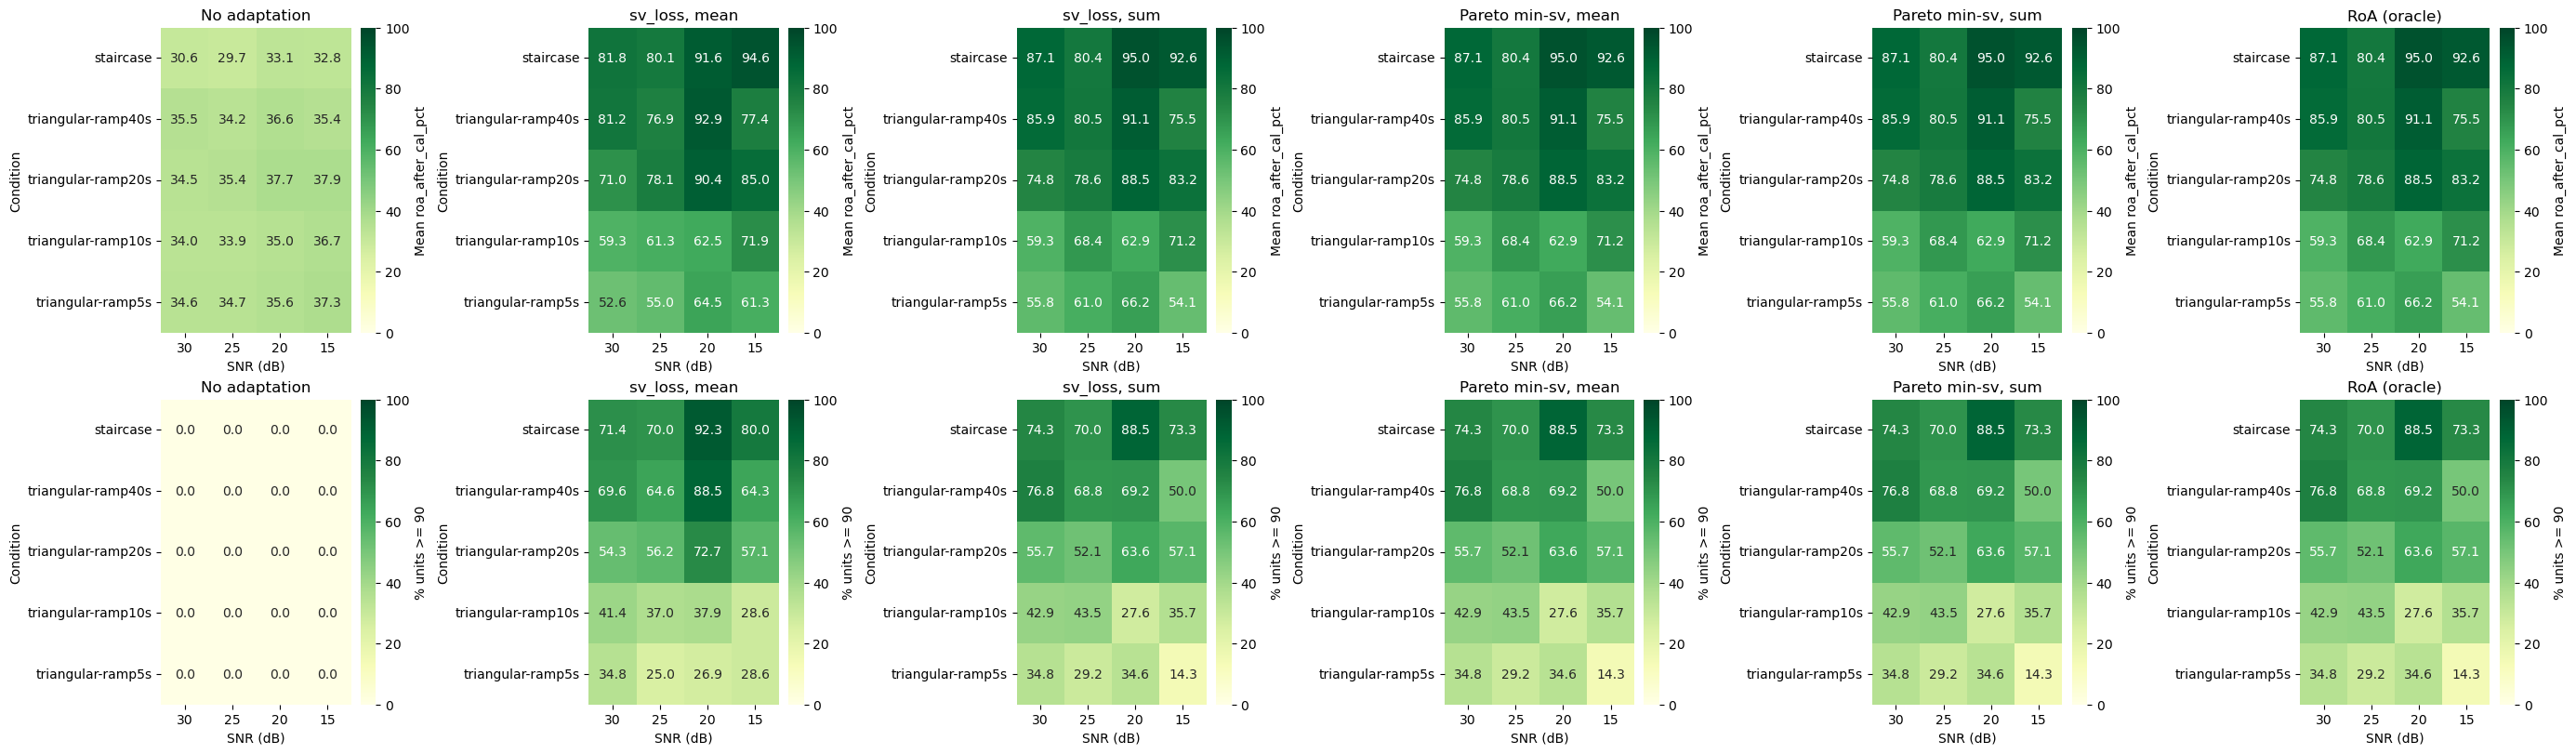

In [ ]:
fig, axs = plt.subplots(2, len(CONFIGS), figsize=(4.6 * len(CONFIGS), 8), layout="constrained")
plot_metric_heatmap(
    units, report.ROA_PCT, CONFIGS, CONDITIONS, SNR_LEVELS, vmin=0, vmax=100, axs=axs[0]
)
plot_metric_heatmap(
    units,
    report.ROA_PCT,
    CONFIGS,
    CONDITIONS,
    SNR_LEVELS,
    agg="pct_ge_threshold",
    threshold=90,
    vmin=0,
    vmax=100,
    axs=axs[1],
)
plt.show()

Gain over no adaptation, unit by unit, averaged per contraction and SNR.

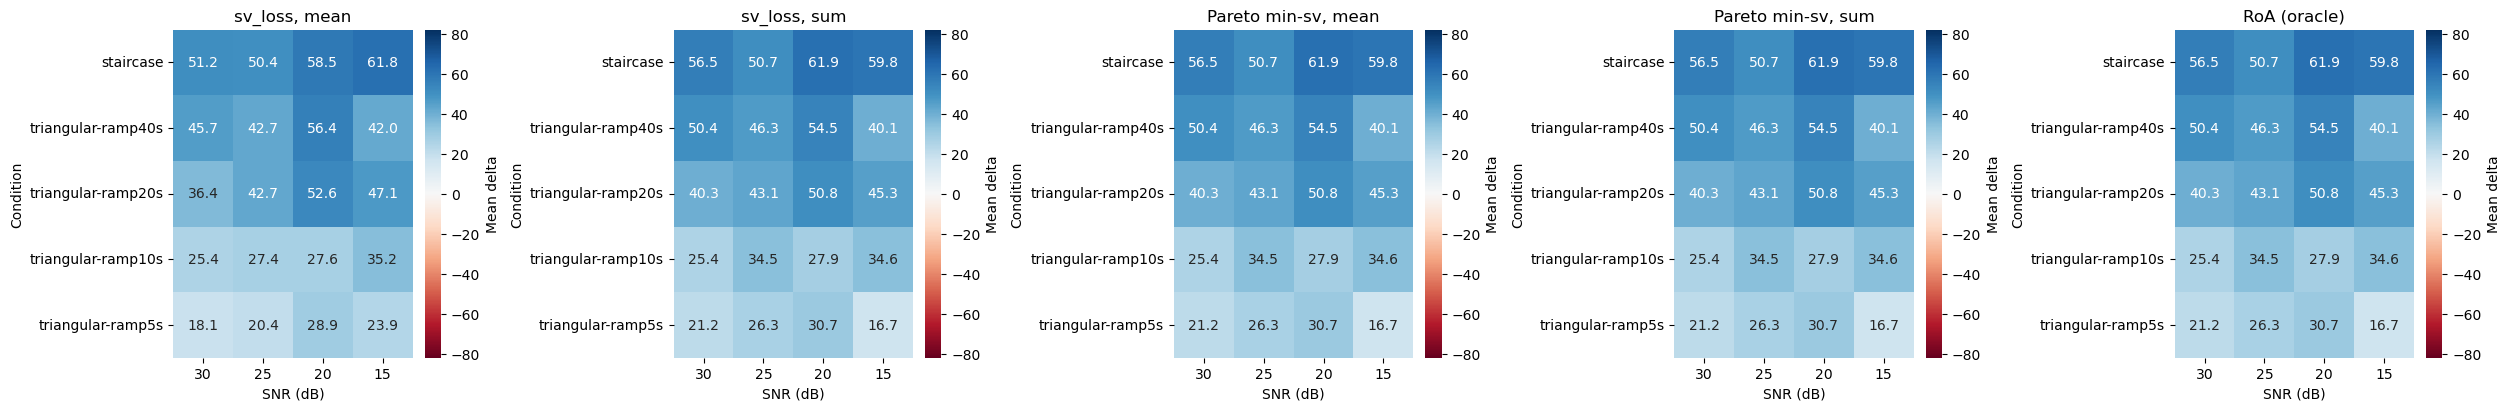

In [ ]:
delta = report.heatmap_delta(units, FIXED)
limit = delta["delta"].abs().max()
plot_metric_heatmap(
    delta, "delta", ADAPTED, CONDITIONS, SNR_LEVELS, vmin=-limit, vmax=limit, cmap="RdBu", center=0
)
plt.show()

### Pool and held-out recordings

The searches only saw the pool's recordings. Pool conditions on other subjects or SNRs, and
the conditions no search saw, show how well each config generalises.

In [ ]:
display(
    units.pivot_table(
        index="config", columns="split", values=report.ROA_PCT, aggfunc="mean"
    ).reindex(index=CONFIGS, columns=list(report.SPLITS))
)

split,pool recordings,"pool conditions, other recordings",held-out conditions
config,,,
No adaptation,34.20,34.95,33.20
"sv_loss, mean",53.22,67.74,80.71
"sv_loss, sum",60.07,69.85,82.84
"Pareto min-sv, mean",60.07,69.85,82.84
"Pareto min-sv, sum",60.07,69.85,82.84
RoA (oracle),60.07,69.85,82.84


## 5. Triangular contractions by phase

Mean RoA in the first isometric hold (including the calibration window), the ramp, and the
last isometric hold, where tracking drifts most without adaptation.

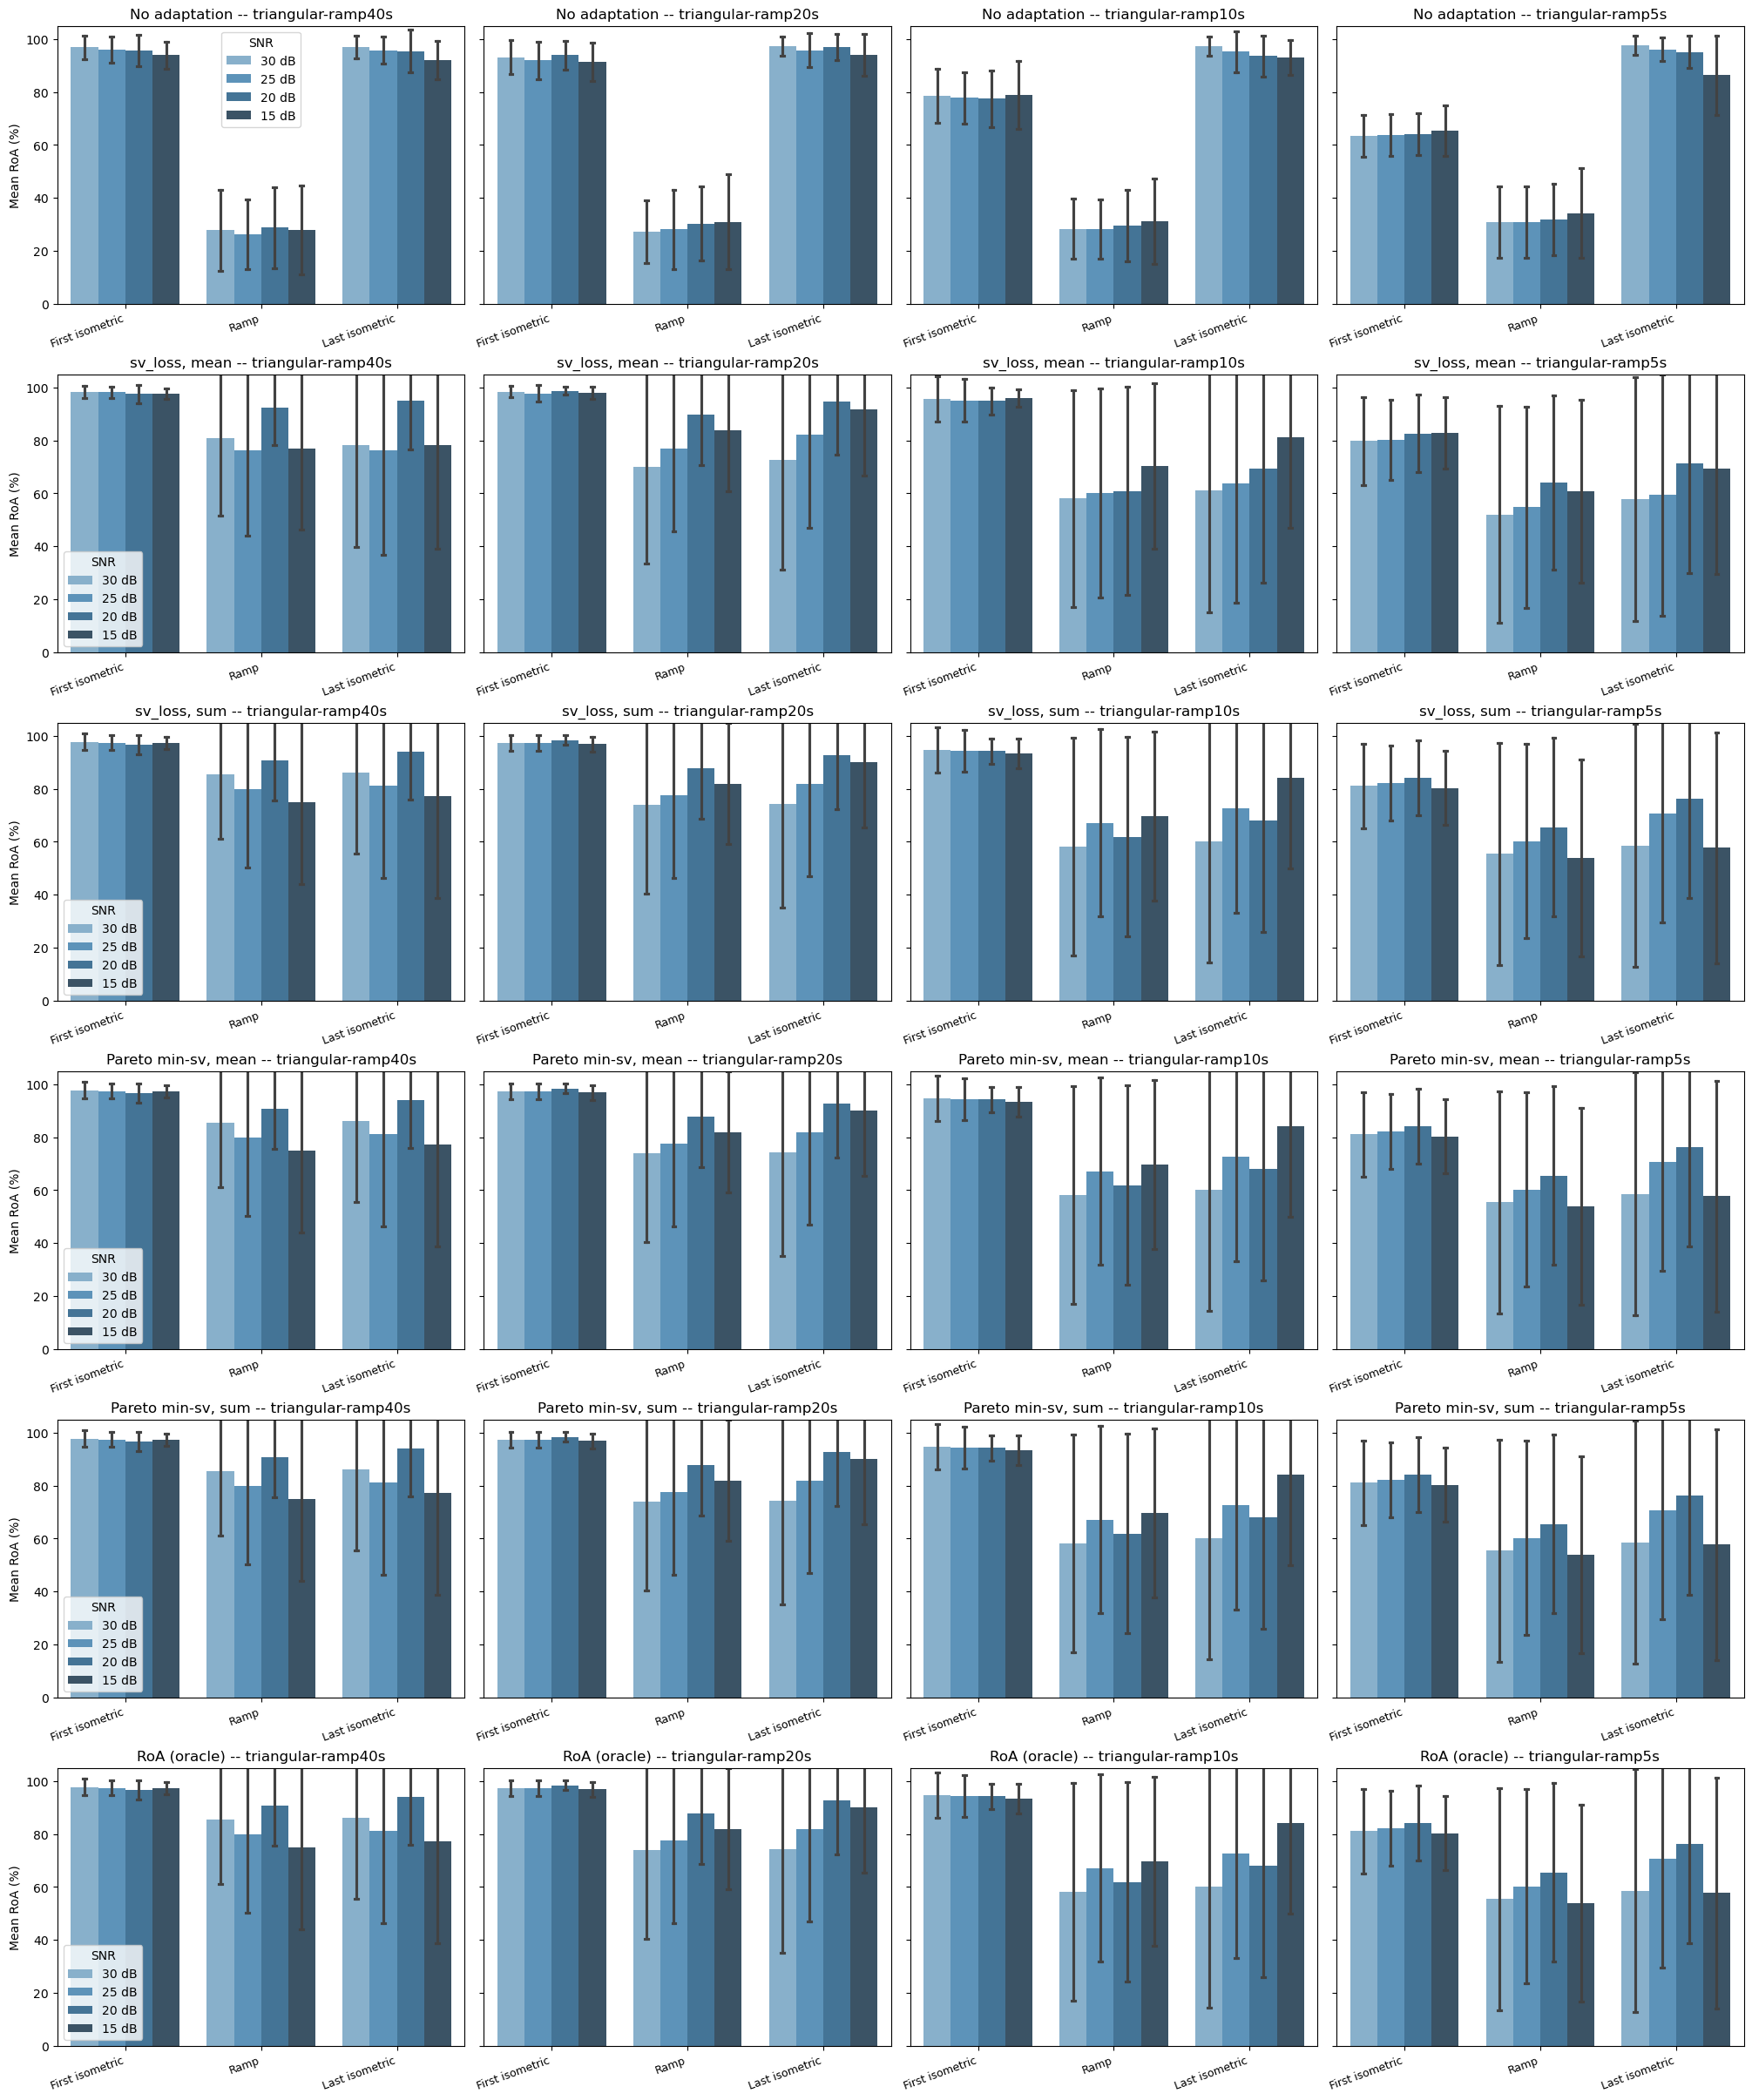

In [ ]:
phases = list(report.PHASES.values())
plot_phase_bar(
    report.phase_long(units), CONFIGS, TRIANGULAR, SNR_LEVELS, phases, {p: p for p in phases}
)
plt.show()

## 6. Objectives and loss aggregation

Unit by unit: averaging against summing `sv_loss` over units, `sv_loss` alone against the
Pareto front, and each unsupervised objective against the ground-truth RoA oracle (the gap
to the upper bound).

In [ ]:
def labels(*branches):
    return [LABELS[b] for b in branches if b in LABELS]


pairs = [
    tuple(labels("sv_mean", "sv_sum")),
    tuple(labels("pareto_mean", "pareto_sum")),
    tuple(labels("sv_mean", "pareto_mean")),
    tuple(labels("sv_sum", "pareto_sum")),
    *[
        (config, LABELS["roa"])
        for config in labels("sv_mean", "sv_sum", "pareto_mean", "pareto_sum")
        if "roa" in LABELS
    ],
]
display(report.paired_summary(units, [pair for pair in pairs if len(pair) == 2]))

,,n_units,mean_before,mean_after,mean_delta,median_before,median_after,median_delta,pct_improved,pct_unchanged,pct_worse,wilcoxon_p
before,after,,,,,,,,,,,
"sv_loss, mean","sv_loss, sum",785,72.18,74.55,2.37,92.52,91.5,-0.29,23.18,32.23,44.59,2.64e-08
"Pareto min-sv, mean","Pareto min-sv, sum",785,74.55,74.55,0.00,91.50,91.5,0.00,0.00,100.00,0.00,NaN
"sv_loss, mean","Pareto min-sv, mean",785,72.18,74.55,2.37,92.52,91.5,-0.29,23.18,32.23,44.59,2.64e-08
"sv_loss, sum","Pareto min-sv, sum",785,74.55,74.55,0.00,91.50,91.5,0.00,0.00,100.00,0.00,NaN
"sv_loss, mean",RoA (oracle),785,72.18,74.55,2.37,92.52,91.5,-0.29,23.18,32.23,44.59,2.64e-08
"sv_loss, sum",RoA (oracle),785,74.55,74.55,0.00,91.50,91.5,0.00,0.00,100.00,0.00,NaN
"Pareto min-sv, mean",RoA (oracle),785,74.55,74.55,0.00,91.50,91.5,0.00,0.00,100.00,0.00,NaN
"Pareto min-sv, sum",RoA (oracle),785,74.55,74.55,0.00,91.50,91.5,0.00,0.00,100.00,0.00,NaN


## 7. Cost

Processing time per batch against the batch's own duration (a real-time factor below 1
keeps up with the signal), and the compute each stage used.

In [ ]:
display(
    report.cost_summary(tables["recordings"], batch_ms=spec.fixed_config().batch_ms).reindex(
        CONFIGS
    )
)
search_time = (
    tables["provenance"]
    .query("stage == 'search'")
    .assign(config=lambda d: d["id"].map(LABELS), run_time_h=lambda d: d["run_time_s"] / 3600)
)
display(search_time.set_index("config")[["run_time_h", "hostname", "cpu"]])

,mean_batch_ms,max_batch_ms,real_time_factor,apply_run_time_s
config,,,,
No adaptation,185.24,257.99,1.85,188.34
"sv_loss, mean",226.17,309.60,2.26,226.25
"sv_loss, sum",247.23,404.34,2.47,246.33
"Pareto min-sv, mean",260.43,540.53,2.60,262.49
"Pareto min-sv, sum",247.79,486.16,2.48,248.54
RoA (oracle),307.22,794.91,3.07,304.94


,run_time_h,hostname,cpu
config,,,
"sv_loss, mean",1.47,cx3-6-23,AMD EPYC 7742 64-Core Processor
"sv_loss, sum",1.18,cx3-5-13,AMD EPYC 7742 64-Core Processor
"Pareto min-sv, mean",1.17,cx3-5-19,AMD EPYC 7742 64-Core Processor
"Pareto min-sv, sum",1.10,cx3-5-19,AMD EPYC 7742 64-Core Processor
RoA (oracle),1.05,cx3-5-28,AMD EPYC 7742 64-Core Processor


## 8. Reproduce

From the repository root, with the `adapt_decomp` environment and the FDSI data
(`adapt-decomp-data get fdsi_benchmark-data`):

```sh
python -m benchmarks.fdsi calibrate --all --n-workers 8
python -m benchmarks.fdsi search --all
python -m benchmarks.fdsi apply --all --n-workers 8
python -m benchmarks.fdsi collect
```

or `bash benchmarks/fdsi/pbs/submit.sh` on a PBS Pro cluster. Every output has a
`*.meta.yaml` next to it with the machine, the git commit and the exact command that
reproduces it.